In [12]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ds = xr.open_dataset("../../NC/compare_diff.nc")
ds = xr.open_dataset("../../NC/compare_diff_region_basin_consistent.nc")

In [13]:
def load_region_matrix(csv_path, lat_size=360, lon_size=720):
    df = pd.read_csv(csv_path)

    region_matrix = np.empty((lat_size, lon_size), dtype=object)
    region_matrix[:] = None

    for _, r in df.iterrows():
        I = int(r["I"]) - 1   # ⚠️ 假设 I/J 从 1 开始
        J = int(r["J"]) - 1
        region_matrix[I, J] = r["Rall"]

    return region_matrix

In [14]:
def excess_kurtosis(x):
    """
    x: 1D numpy array (no NaN)
    return: excess kurtosis
    """
    mu = x.mean()
    sigma = x.std()
    return np.mean(((x - mu) / sigma) ** 4) - 3


In [15]:
def global_kurtosis_timeseries(da, years):
    results = []

    for ti, year in enumerate(years):
        arr = da.isel(time=ti).values
        arr = arr[~np.isnan(arr)]

        kurt = excess_kurtosis(arr)

        results.append({
            "year": year,
            "scope": "global",
            "region": "ALL",
            "kurtosis": kurt
        })

    return results


In [16]:
years = list(range(2010, 2101, 10))

ds = xr.open_dataset("../../NC/compare_diff_region_basin_consistent.nc")

res_global = []
res_global += global_kurtosis_timeseries(ds["region_agri_diff"], years)
for r in res_global:
    r["mode"] = "region"

res_global_basin = global_kurtosis_timeseries(ds["basin_agri_diff"], years)
for r in res_global_basin:
    r["mode"] = "basin"

res_global.extend(res_global_basin)


In [17]:
region_matrix = load_region_matrix(
    "../../CSV/gridset/RIJ_17regions.csv",
    360, 720
)

regions = sorted({
    r for r in region_matrix.flatten()
    if isinstance(r, str) and r.strip() != ""
})


In [18]:
def regional_kurtosis_timeseries(
    da,
    years,
    region_matrix,
    regions,
):
    results = []

    region_flat = region_matrix.flatten()

    for ti, year in enumerate(years):
        print(f"Processing year {year}")

        arr = da.isel(time=ti).values
        arr_flat = arr.flatten()

        for reg in regions:
            mask = region_flat == reg

            # 安全检查
            if mask.sum() < 10:
                continue

            x_reg = arr_flat[mask]
            x_reg = x_reg[~np.isnan(x_reg)]

            kurt = excess_kurtosis(x_reg)

            results.append({
                "year": year,
                "scope": "regional",
                "region": reg,
                "kurtosis": kurt
            })

    return results


In [19]:
results_all = []

print("\n=== REGION MODE ===")
res_region = regional_kurtosis_timeseries(
    ds["region_agri_diff"],
    years,
    region_matrix,
    regions
)
for r in res_region:
    r["mode"] = "region"
results_all.extend(res_region)

print("\n=== BASIN MODE ===")
res_basin = regional_kurtosis_timeseries(
    ds["basin_agri_diff"],
    years,
    region_matrix,
    regions
)
for r in res_basin:
    r["mode"] = "basin"
results_all.extend(res_basin)



=== REGION MODE ===
Processing year 2010
Processing year 2020


C:\Users\ZSR\AppData\Local\Temp\ipykernel_1664\2417816895.py:6: RuntimeWarning: Mean of empty slice.
  mu = x.mean()
d:\anaconda\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
d:\anaconda\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
d:\anaconda\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
d:\anaconda\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
d:\anaconda\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Processing year 2030
Processing year 2040
Processing year 2050


C:\Users\ZSR\AppData\Local\Temp\ipykernel_1664\2417816895.py:8: RuntimeWarning: invalid value encountered in divide
  return np.mean(((x - mu) / sigma) ** 4) - 3


Processing year 2060
Processing year 2070
Processing year 2080
Processing year 2090
Processing year 2100

=== BASIN MODE ===
Processing year 2010
Processing year 2020
Processing year 2030
Processing year 2040
Processing year 2050
Processing year 2060
Processing year 2070
Processing year 2080
Processing year 2090
Processing year 2100


In [21]:
df_kurt = pd.DataFrame(res_global + results_all)

df_kurt = df_kurt[
    ["year", "scope", "region", "mode", "kurtosis"]
]

df_kurt["kurtosis"] = df_kurt["kurtosis"].round(3)

df_kurt.to_csv(
    "../../CSV/kurtosis_interannual_diff_global_and_regional_consistent.csv",
    index=False
)

print("[Saved] kurtosis_interannual_diff_global_and_regional.csv")


[Saved] kurtosis_interannual_diff_global_and_regional.csv


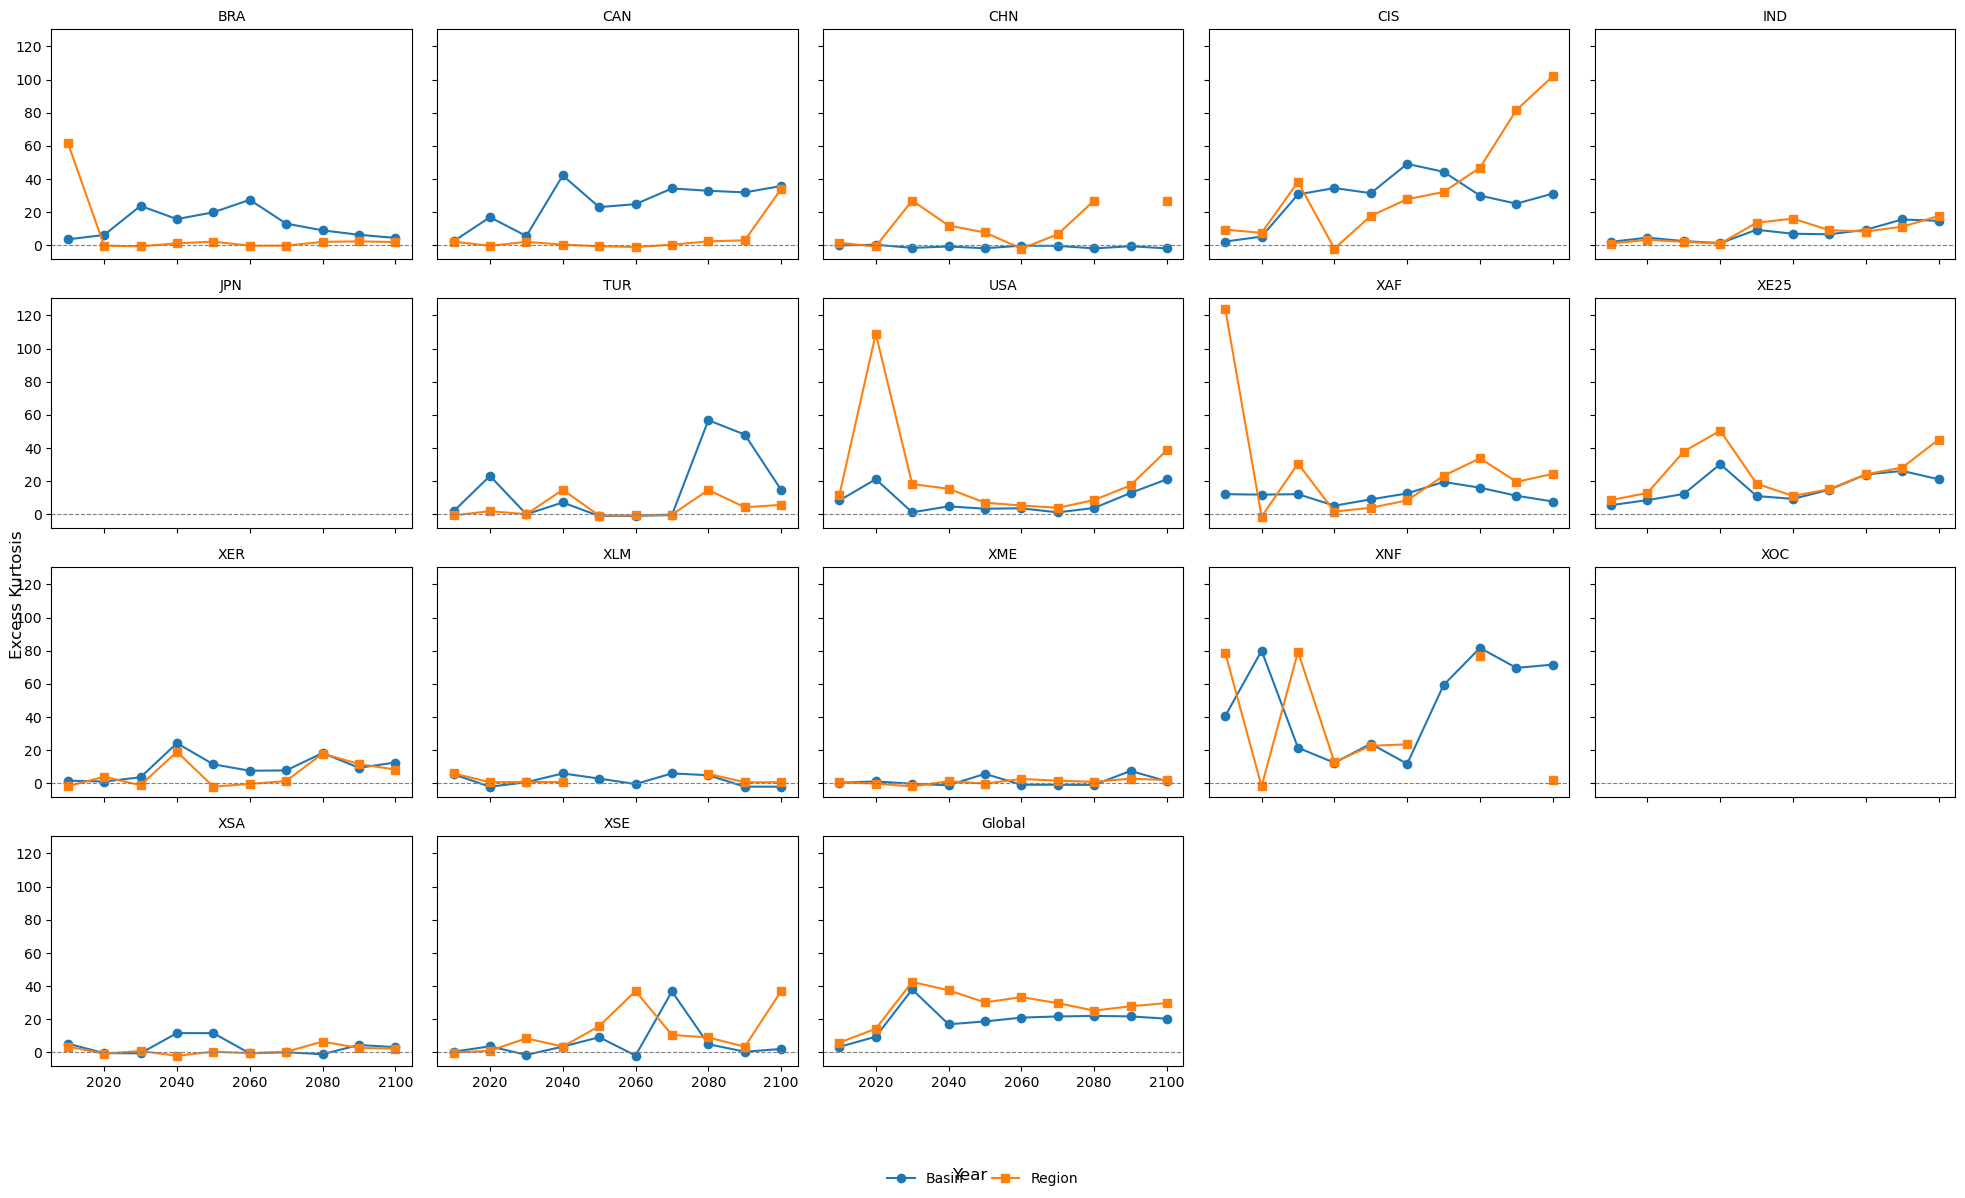

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. 准备数据
# =========================
df_g = df_kurt.query("scope == 'global'")
df_r = df_kurt.query("scope == 'regional'")
regions = sorted(df_r["region"].unique().tolist()) + ["ALL"]

n = len(regions)   # 应该是 18

# =========================
# 2. 子图布局
# =========================
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# =========================
# 3. 画每个 region
# =========================
for ax, reg in zip(axes, regions):

    if reg == "ALL":
        d = df_g
        title = "Global"
    else:
        d = df_r[df_r["region"] == reg]
        title = reg

    for mode, marker in zip(["basin", "region"], ["o", "s"]):
        dm = d[d["mode"] == mode]
        ax.plot(
            dm["year"],
            dm["kurtosis"],
            marker=marker,
            linewidth=1.5,
            label=mode.capitalize()
        )

    ax.axhline(0, linestyle="--", linewidth=0.8, color="gray")
    ax.set_title(title, fontsize=10)

# =========================
# 4. 删除多余子图
# =========================
for i in range(n, len(axes)):
    fig.delaxes(axes[i])

# =========================
# 5. 统一标签 & 图例
# =========================
fig.supxlabel("Year")
fig.supylabel("Excess Kurtosis")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(
    "../../plot/interannual_diff_kurtosis_global_and_17regions.png",
    dpi=300
)
plt.show()


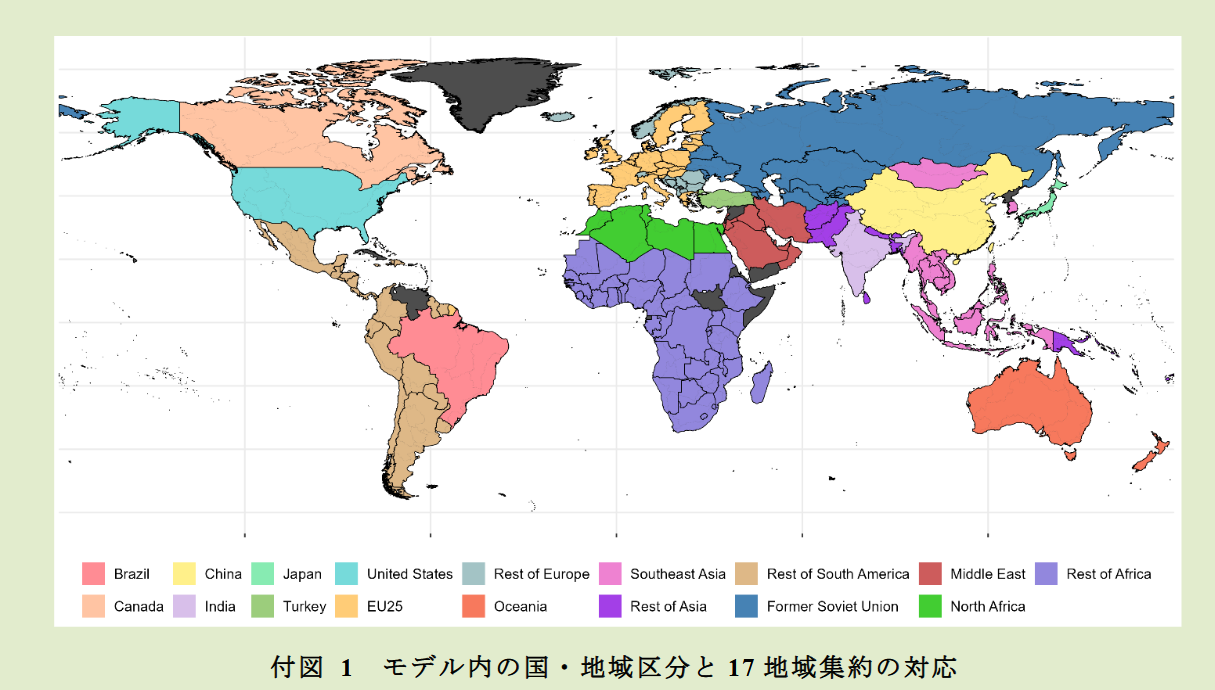

In [26]:
ds = xr.open_dataset("../../NC/compare_diff_region_basin_consistent.nc")
da_2010_region = ds["region_agri_diff"].sel(time="2010-01-01")
# region_matrix: (lat, lon) object array
mask_xaf = (region_matrix == "XAF")
x_xaf_2010 = da_2010_region.values[mask_xaf]
x_xaf_2010 = x_xaf_2010[~np.isnan(x_xaf_2010)]
print("XAF 2010 (region mode)")
print("有效格点数:", x_xaf_2010.size)
print("非零格点数:", np.sum(x_xaf_2010 != 0))
print("最大值:", x_xaf_2010.max())
print("最小值:", x_xaf_2010.min())
print("均值:", x_xaf_2010.mean())
print("标准差:", x_xaf_2010.std())


XAF 2010 (region mode)
有效格点数: 832
非零格点数: 633
最大值: 0.12
最小值: -6.0000457e-07
均值: 0.007684494
标准差: 0.006408392


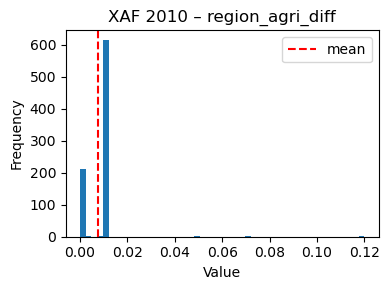

In [27]:
plt.figure(figsize=(4,3))
plt.hist(x_xaf_2010, bins=50)
plt.axvline(x_xaf_2010.mean(), color="r", linestyle="--", label="mean")
plt.title("XAF 2010 – region_agri_diff")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
